# 03 — Exploratory Data Analysis
Visualize patterns, correlations, and distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

data_path = Path('../../data/plant_health_data.csv')
if not data_path.exists():
    data_path = Path('../data/plant_health_data.csv')

df = pd.read_csv(data_path)
df = df.drop(columns=['Timestamp', 'Plant_ID'])

import os
os.makedirs('../../outputs/plots', exist_ok=True)

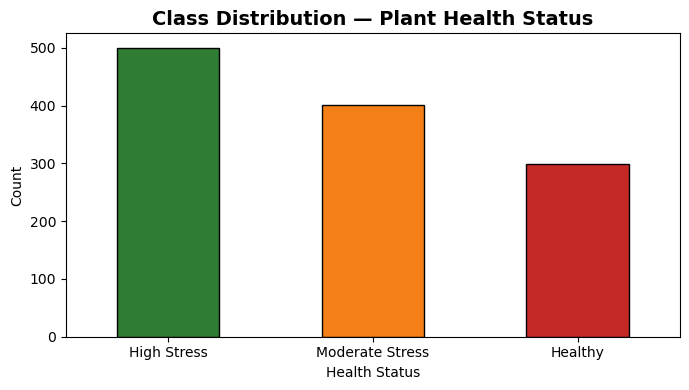

In [2]:
# 1. Class Distribution
plt.figure(figsize=(7, 4))
colors = ['#2E7D32', '#F57F17', '#C62828']
df['Plant_Health_Status'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Class Distribution — Plant Health Status', fontsize=14, fontweight='bold')
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../outputs/plots/class_distribution.png', dpi=150)
plt.show()

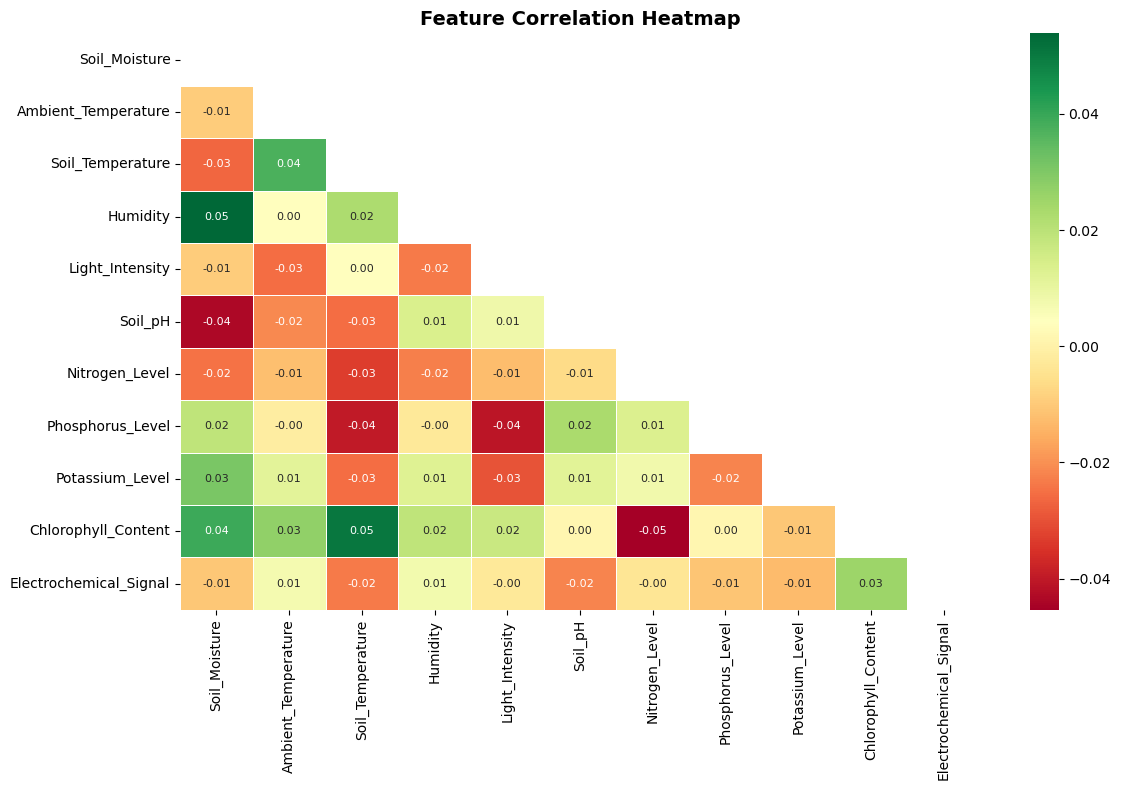

In [3]:
# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/plots/correlation_heatmap.png', dpi=150)
plt.show()

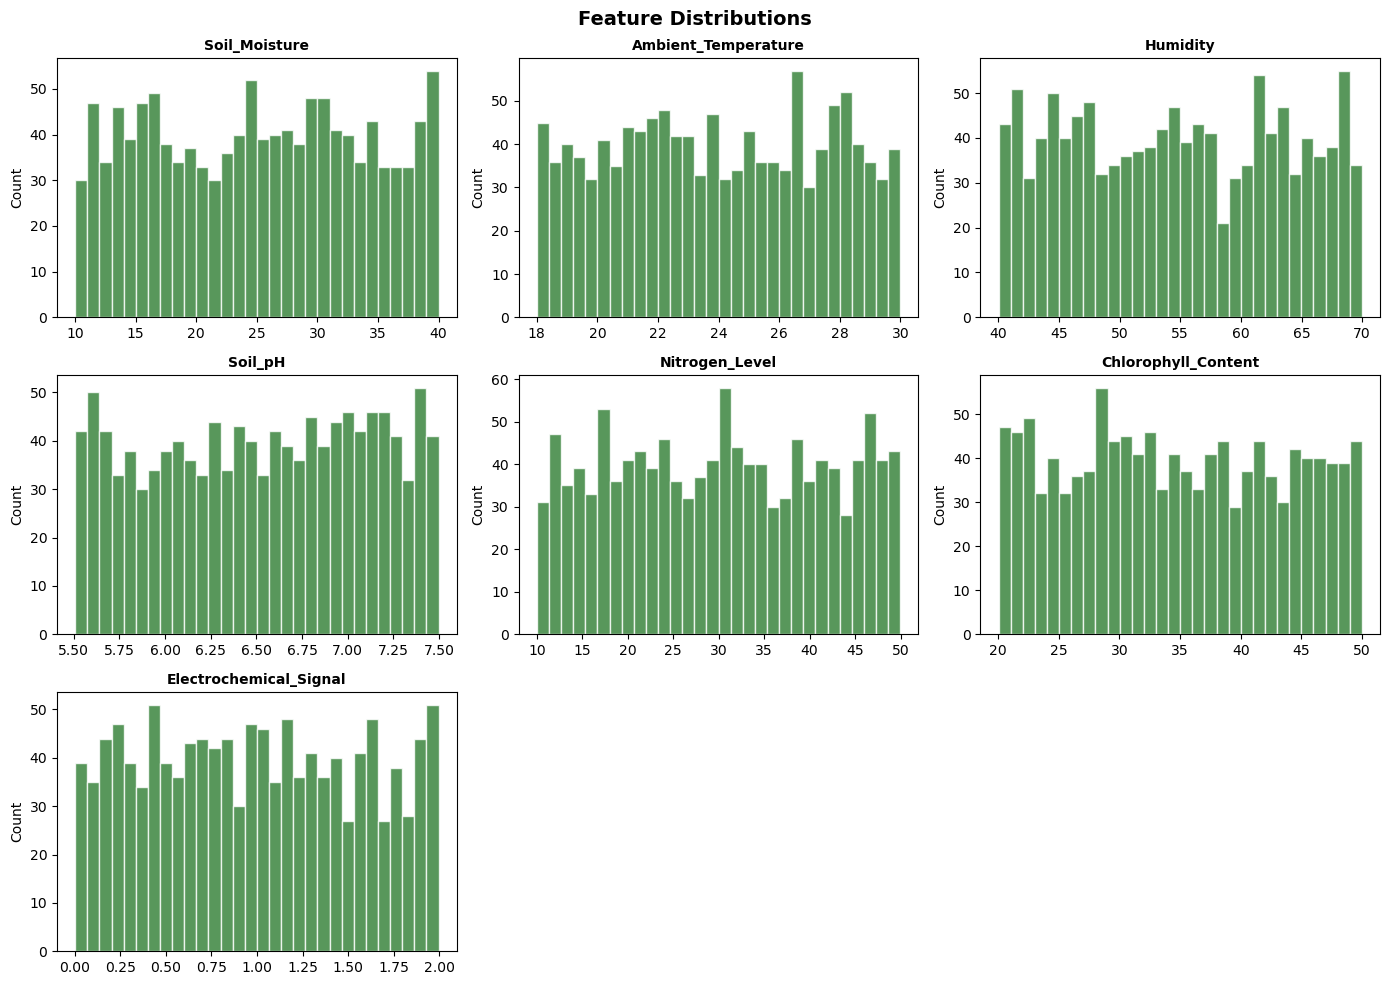

In [4]:
# 3. Feature Distributions
features = ['Soil_Moisture', 'Ambient_Temperature', 'Humidity',
            'Soil_pH', 'Nitrogen_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, color='#2E7D32', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/plots/feature_distributions.png', dpi=150)
plt.show()

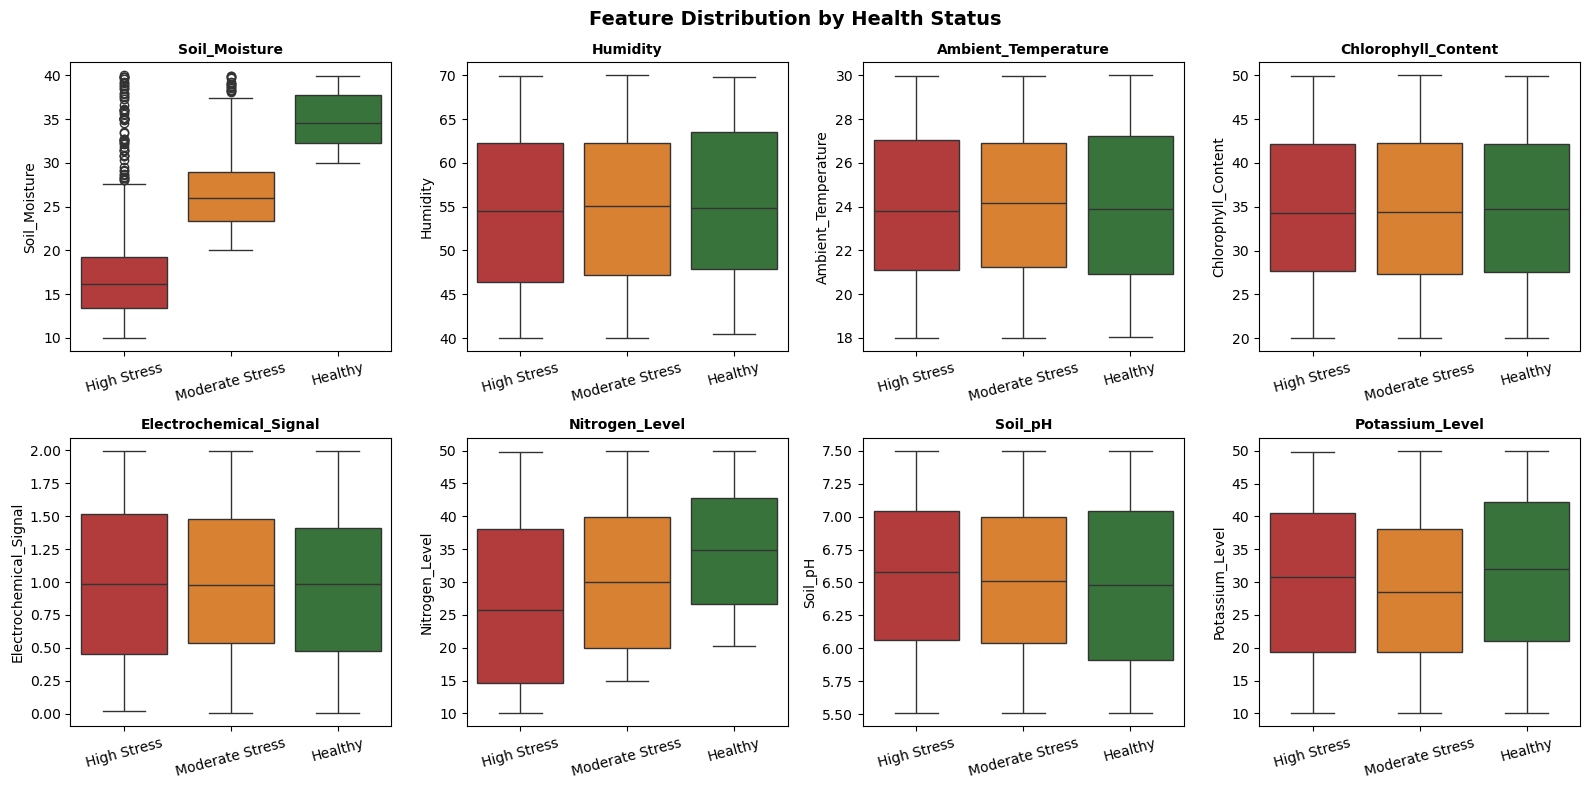

In [5]:
# 4. Boxplots — Features vs Health Status
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
key_features = ['Soil_Moisture', 'Humidity', 'Ambient_Temperature',
                'Chlorophyll_Content', 'Electrochemical_Signal',
                'Nitrogen_Level', 'Soil_pH', 'Potassium_Level']
palette = {'Healthy': '#2E7D32', 'Moderate Stress': '#F57F17', 'High Stress': '#C62828'}
for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='Plant_Health_Status', y=feat, ax=axes[i], palette=palette)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Feature Distribution by Health Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/plots/boxplots.png', dpi=150)
plt.show()

In [6]:
# 5. Key Insight Summary
print("=" * 55)
print("KEY INSIGHTS FROM EDA")
print("=" * 55)
for feat in ['Chlorophyll_Content', 'Electrochemical_Signal', 'Soil_Moisture', 'Humidity']:
    grp = df.groupby('Plant_Health_Status')[feat].mean()
    print(f"\n{feat}:")
    for status, val in grp.items():
        print(f"  {status:<20} Mean = {val:.2f}")

KEY INSIGHTS FROM EDA

Chlorophyll_Content:
  Healthy              Mean = 34.97
  High Stress          Mean = 34.76
  Moderate Stress      Mean = 34.57

Electrochemical_Signal:
  Healthy              Mean = 0.97
  High Stress          Mean = 1.00
  Moderate Stress      Mean = 0.99

Soil_Moisture:
  Healthy              Mean = 34.91
  High Stress          Mean = 18.08
  Moderate Stress      Mean = 26.56

Humidity:
  Healthy              Mean = 55.36
  High Stress          Mean = 54.40
  Moderate Stress      Mean = 55.03
